In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../notebooks/DATA/mushrooms.csv')

In [3]:
X = df.drop('class', axis=1)

In [4]:
X = pd.get_dummies(X, drop_first=True)

In [5]:
y = df['class']

In [6]:
from sklearn.model_selection import train_test_split


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [8]:
from sklearn.ensemble import GradientBoostingClassifier

In [9]:
from sklearn.model_selection import GridSearchCV

In [11]:
param_grid = {
    'n_estimators': [50,100],
    'learning_rate': [0.1, 0.05, 0.2],
    'max_depth':[3,4,5]
    
}

In [12]:
gb_model = GradientBoostingClassifier()

In [13]:
grid_model = GridSearchCV(gb_model, param_grid)

In [14]:
grid_model.fit(X_train, y_train)

,estimator,GradientBoostingClassifier()
,param_grid,"{'learning_rate': [0.1, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [50, 100]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [15]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score

In [16]:
grid_model.best_params_

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}

In [17]:
preds = grid_model.predict(X_test)

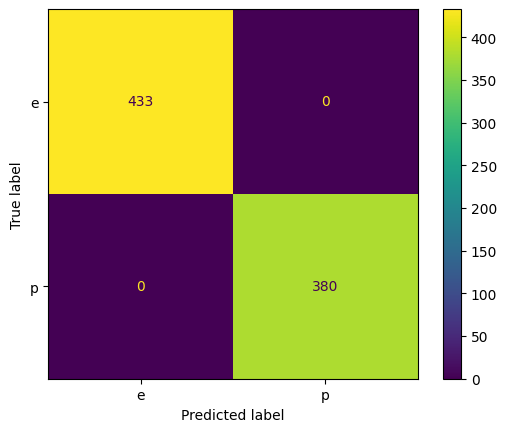

In [18]:
ConfusionMatrixDisplay.from_estimator(grid_model, X_test, y_test)

In [19]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       433
           p       1.00      1.00      1.00       380

    accuracy                           1.00       813
   macro avg       1.00      1.00      1.00       813
weighted avg       1.00      1.00      1.00       813



In [25]:
feat_import = grid_model.best_estimator_.feature_importances_

In [29]:
imp_feats = pd.DataFrame(index=X.columns, data=feat_import, columns=['Importance'])

In [30]:
imp_feats = imp_feats[imp_feats['Importance'] > 0.0005]

In [31]:
imp_feats

,Importance
cap-surface_g,0.002168
bruises_t,0.080064
odor_f,0.015921
odor_l,0.003277
odor_n,0.616953
odor_p,0.015224
gill-spacing_w,0.003782
gill-size_n,0.001055
stalk-root_b,0.000656
stalk-root_c,0.099076


<Axes: xlabel='None', ylabel='Importance'>

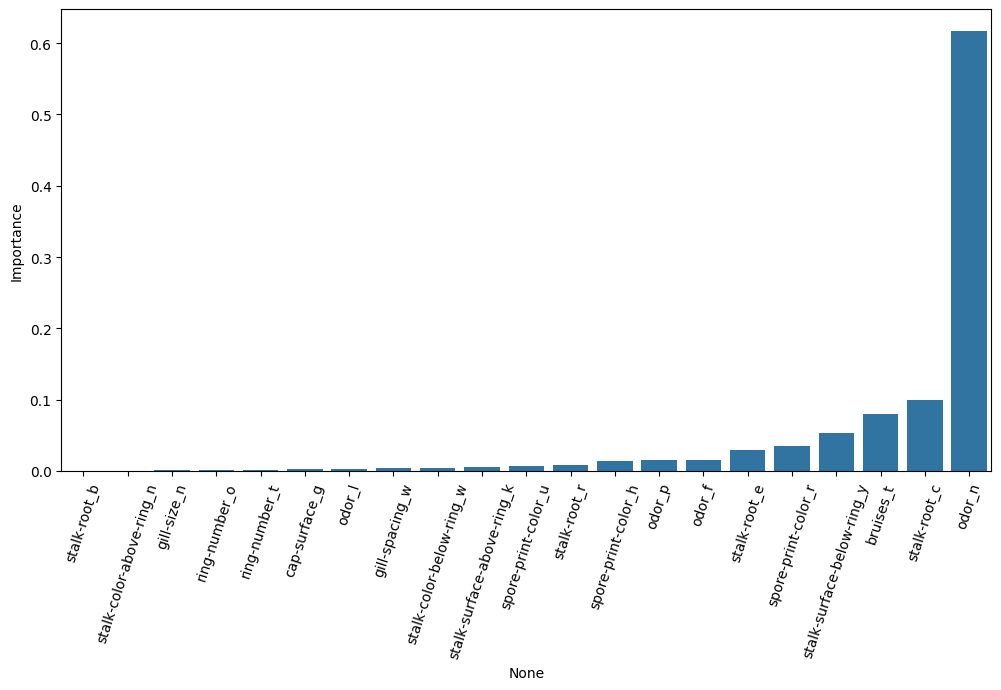

In [36]:
imp_feats = imp_feats.sort_values('Importance')
plt.figure(figsize=(12,6), dpi=100)
plt.xticks(rotation=72)
sns.barplot(data=imp_feats, x=imp_feats.index, y='Importance')